In [4]:
!pip install git+https://github.com/mcgilldinglab/RAMEN.git@development

  Cloning https://github.com/mcgilldinglab/RAMEN.git (to revision development) to /tmp/pip-req-build-s5z5ucxx
  Running command git clone --filter=blob:none --quiet https://github.com/mcgilldinglab/RAMEN.git /tmp/pip-req-build-s5z5ucxx
  Running command git checkout -b development --track origin/development
  Switched to a new branch 'development'
  Branch 'development' set up to track remote branch 'development' from 'origin'.
  Resolved https://github.com/mcgilldinglab/RAMEN.git to commit 4adba84c501bc353a146576838f62f5cdf78ca9f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 7.4 MB/s eta 0:00:00


In [13]:
from ramen.Ramen import Ramen

ramen_bowl = Ramen("long_500.csv", "Long Covid", 0)

Starting removing vars with too few values, vectorizing dataframe, and initializing mutual information matrix, this might take a few minutes.
Removed 0 variables because of insufficient data. If deleted too many, please adjust the bad_var_threshold
done


In [15]:
# Run with default parameters
# random_walk(
#     self,
#     num_exp=10,
#     num_walks=50000,
#     num_steps=7,
#     p_value=0.05,
#     correction="no_correction",
# )

#Shorter run for demo purposes
ramen_bowl.random_walk(
    num_exp=10,
    num_walks=10000,
    num_steps=7,
    p_value=0.05,
    correction="no_correction"
)

Optimization terminated successfully.
         Current function value: 0.964349
         Iterations: 11
         Function evaluations: 12
         Gradient evaluations: 12


In [16]:
# Run with default parameters
# genetic_algorithm(
#     self,
#     num_candidates=10,
#     end_thresh=0.01,
#     mutate_num=100,
#     best_cand_num=10,
#     bad_reprod_accept=10,
#     reg_factor=0.01,
#     hard_stop=100,
# )

ramen_bowl.genetic_algorithm(
    num_candidates=10,
    end_thresh=0.01,
    mutate_num=100,
    best_cand_num=10,
    bad_reprod_accept=10,
    reg_factor=0.01,
    hard_stop=100,
)

84
initializing scorer
done initializing scorer
making candidates
Finished making candidates in: 0.24070988800031046
starting Genetic Algorithm
-46.45379558775664
generation: 0 best: -45.051883757424115
generation: 1 best: -44.18262068456967
generation: 2 best: -42.15385349092591
generation: 3 best: -40.60327952182431
generation: 4 best: -38.90320556157646
generation: 5 best: -37.86293522166419
generation: 6 best: -36.47515222312667
generation: 7 best: -35.03268743285941
generation: 8 best: -34.15575190712848
generation: 9 best: -33.53400685910494
generation: 10 best: -32.78105478341299
generation: 11 best: -29.359115913221082
generation: 12 best: -28.573310307993097
generation: 13 best: -28.573310307993097
generation: 14 best: -27.764190993279644
generation: 15 best: -26.900892573397286
generation: 16 best: -25.74709776051901
generation: 17 best: -24.855818647094697
generation: 18 best: -24.023318949100318
generation: 19 best: -23.36978156471127
generation: 20 best: -22.89405535054903

In [18]:
# Save for Subsequenet Analysis
# {
#     "DATASET_PATH": self.csv_data_name,
#     "END_VARIABLE": self.end_string,
#     "RW_NETWORK": self.signif_edges,
#     "FINAL_NETWORK": list(self.network.edges()),
#     "RW_EDGE_VISIT": make_edge_visit_payload(self.edge_visit_dict),
#     "END_VAR_ARRIVALS": self.var_arrival_count_tracker,
# }
ramen_results = ramen_bowl.export_ramen_as_dict()


In [50]:
# Analyze Importance to Source Node
result = [(key[0], value) for key, value in ramen_results['RW_EDGE_VISIT'].items() if key[1] == "Long Covid"]
result


[('Age au recrutement:', np.float64(7.8)),
 ('Sex at birth:', np.float64(7.7)),
 ('Height in m:', np.float64(9.2)),
 ('Weight in kg:', np.float64(7.5)),
 ('BMI:', np.float64(7.0)),
 ('Smoking status:', np.float64(7.0)),
 ('Electronic cigarettes?', np.float64(7.8)),
 ('Drugs?', np.float64(6.4)),
 ('Please specify drugs used. (choice=Cannabis)', np.float64(8.7)),
 ('Please specify drugs used. (choice=Cocaine)', np.float64(7.3)),
 ('Please specify drugs used. (choice=Amphetamines)', np.float64(7.5)),
 ('Please specify drugs used. (choice=Opiods)', np.float64(8.3)),
 ('Please specify drugs used. (choice=Other)', np.float64(9.4)),
 ('Main (or Primary) Diagnosis relative to this hospitalisation:',
  np.float64(62.0)),
 ('Is the participant employed as a Healthcare Worker?  ', np.float64(5.8)),
 ('Is the participant employed in a Microbiology Laboratory?  ',
  np.float64(8.3)),
 ('Patient pregnant?', np.float64(6.5)),
 ('Prior transient ischemic attack (TIA) ?', np.float64(7.5)),
 ('Asthma ?'

In [31]:
# Code for drawing heatmaps

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

class HeatmapAction:
    def __init__(self, csv_file, var1, var2, destination_folder=None, var_name_mapping=None):
        self.csv = csv_file
        self.var1 = var1
        self.var2 = var2
        self.destination_folder = destination_folder
        self.var_name_mapping = var_name_mapping or {}

    def enact(self, ignore_values=None):
        print(f"Working on ({self.var1}, {self.var2}).")
        if ignore_values is None:
            ignore_values = []
        plot_heatmap(
            self.csv,
            self.var1,
            self.var2,
            self.var_name_mapping,
            ignore_values,
            destination_folder=self.destination_folder
        )

    def __str__(self):
        return f"Heatmap between: <{self.var1}> and <{self.var2}> saved to {self.destination_folder}"


def reverse_dictionary(dictionary):
    """Reverse inner dictionaries: {var: {discrete: real}} -> {var: {real: discrete}}"""
    new_dictionary = {}
    for var, mappings in dictionary.items():
        new_dictionary[var] = {v: k for k, v in mappings.items()}
    return new_dictionary


def plot_heatmap(csv_file, var1, var2, var_name_mapping, ignore_values, destination_folder=None):
    df = pd.read_csv(csv_file)

    # Use pandas for safe NaN handling (works for strings & numbers)
    variable_1_array = df[var1].replace(ignore_values, np.nan)
    variable_2_array = df[var2].replace(ignore_values, np.nan)

    # Drop rows where either variable is NaN
    valid_df = df.loc[variable_1_array.notna() & variable_2_array.notna(), [var1, var2]].copy()
    valid_df[var1] = try_floating(valid_df[var1])
    valid_df[var2] = try_floating(valid_df[var2])

    # Bin numeric values if necessary
    if should_bin(valid_df[var1]):
        valid_df[var1] = pd.cut(valid_df[var1].astype(float), bins=10, precision=1)
    if should_bin(valid_df[var2]):
        valid_df[var2] = pd.cut(valid_df[var2].astype(float), bins=10, precision=1)

    # Calculate frequency table and percentages
    cross_tab = pd.crosstab(valid_df[var1], valid_df[var2], normalize='index')
    percentage_table = (cross_tab * 100).round(2)

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.set(font_scale=2)
    sns.heatmap(
        percentage_table,
        annot=False,
        cmap='YlGnBu',
        fmt=".2f",
        linewidths=0.5,
        xticklabels=percentage_table.columns,
        yticklabels=percentage_table.index
    )

    plt.xlabel(get_from_mapping(var2, var_name_mapping), fontsize=30)
    plt.ylabel(get_from_mapping(var1, var_name_mapping), fontsize=30)
    plt.title(f"{var1} vs. {var2}", fontsize=30)
    plt.tight_layout()

    # Show plot instead of saving
    plt.show()


def get_from_mapping(key, mapping):
    return mapping.get(key, key)


def should_bin(array):
    """Decide whether numeric array should be binned into categories."""
    if not pd.api.types.is_numeric_dtype(array):
        return False
    return array.nunique() > 10


def try_floating(array):
    """Convert array to numeric if possible; leave strings intact."""
    return pd.to_numeric(array, errors="ignore")


def draw_heatmaps(variables_against_target, additional_pairs, target_node, csv, ignore_values=None):
    if ignore_values is None:
        ignore_values = []

    pairs = [(var, target_node) for var in variables_against_target] + additional_pairs
    for var1, var2 in pairs:
        heatmap_action = HeatmapAction(csv, var1, var2, destination_folder=None)
        heatmap_action.enact(ignore_values)


Working on (Sex at birth:, Long Covid).


/tmp/ipython-input-281921203.py:96: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  return pd.to_numeric(array, errors="ignore")


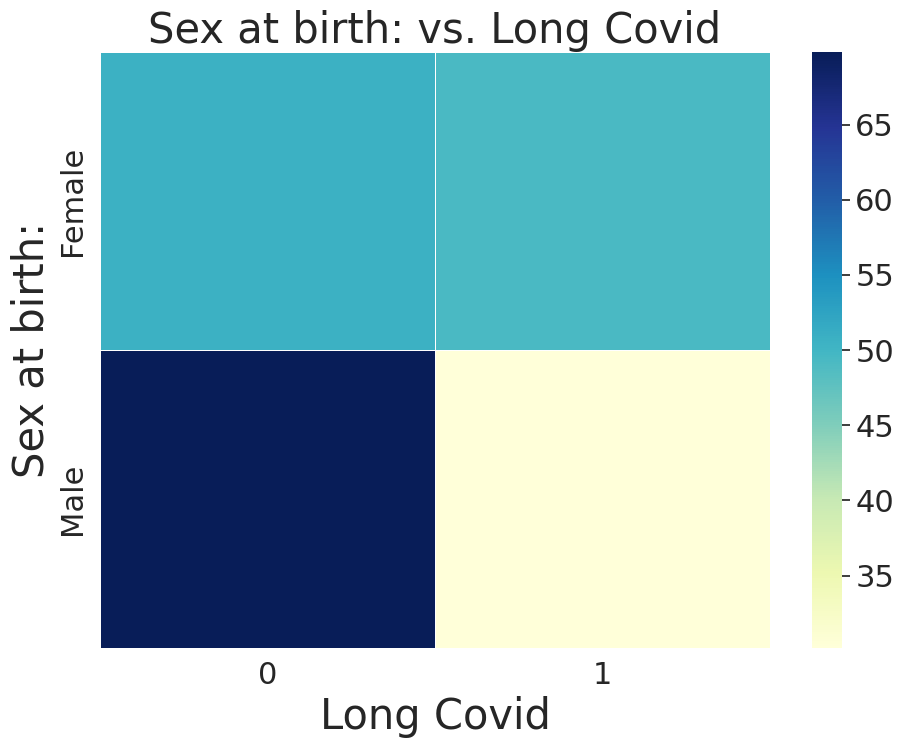

In [30]:
draw_heatmaps(
    ["Sex at birth:"],
    [],
    "Long Covid",
    "long_500.csv",
    ["ERROR", "nan", "no data", "<4", ">150*", "LESS THAN 5", "LESS THAN 0.4", -999],
)


Working on (BMI:, Long Covid).


/tmp/ipython-input-2346189371.py:98: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  return pd.to_numeric(array, errors="ignore")


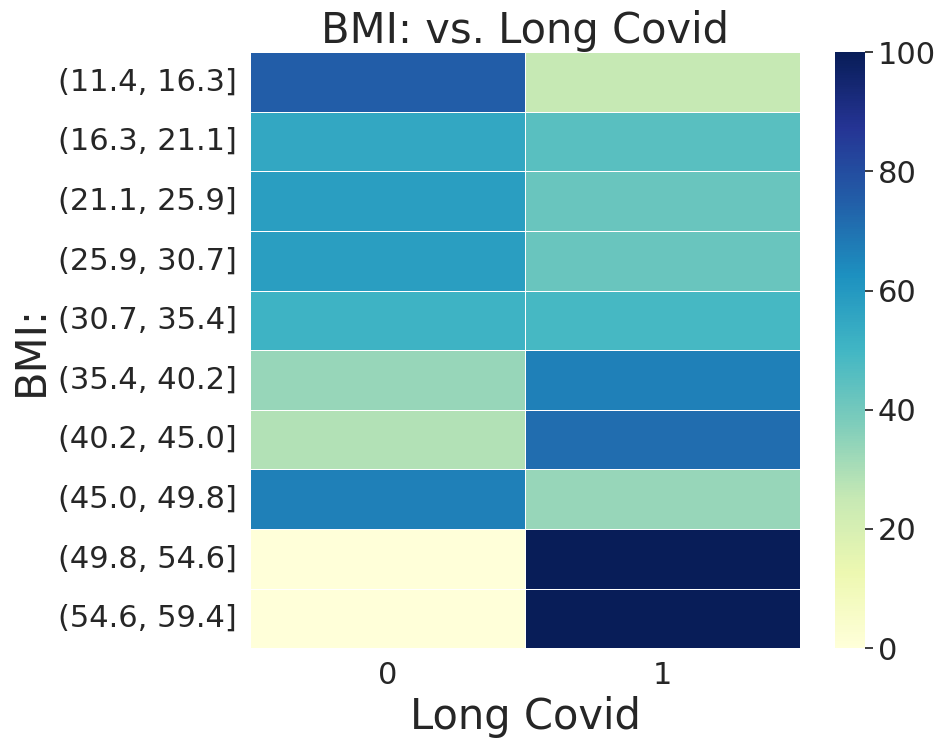

In [32]:
draw_heatmaps(
    ["BMI:"],
    [],
    "Long Covid",
    "long_500.csv",
    ["ERROR", "nan", "no data", "<4", ">150*", "LESS THAN 5", "LESS THAN 0.4", -999],
)

In [36]:
from networkx import nodes

strength_categories = ["strongest", "strong", "okay", "weaker"]

def make_cytoscape_files(nx_graph, sif_name, noa_name, end_var, classifications, visit_dict = None, keep_factor=1):
    make_sif_file(nx_graph, sif_name, visit_dict, keep_factor)
    make_noa_file(nx_graph, noa_name, visit_dict, end_var, classifications)

def make_sif_file(nx_graph, sif_name, visit_dict, keep_factor):
    sif_file = open(sif_name, "w")
    edges = get_sort_edges_with_visit_dict(nx_graph, visit_dict)
    kept_edges = [edge[0] for edge in edges[0:int(len(edges)*keep_factor)]]

    counter = 0
    splitter = int(len(kept_edges)/4)
    for edge in kept_edges:
        x, y = edge
        string = x + "\t" + strength_categories[min(int(counter / splitter), 3)] + "\t" + y + "\n"
        counter += 1
        sif_file.write(string)
    sif_file.close()

def make_noa_file(nx_graph, noa_name, visit_dict, end_var, classifications, var_name_mapping = {}):
    noa = open(noa_name, 'w')
    noa.write("name = CATEGORY = WEIGHT\n")
    node_tuples = get_sort_nodes_with_visit_dict(nx_graph, visit_dict, end_var)

    for node_tup in node_tuples:
        classification = "other"
        node_str = node_tup[0]
        if node_str in classifications:
            classification = classifications[node_str]
        write_string = get_from_mapping(var_name_mapping, node_str) + " = " + classification + " = " + str(node_tup[1]) + "\n"
        noa.write(write_string)
    noa.close()
    return

def get_sort_edges_with_visit_dict(nx_graph, visit_dict):
    edges_with_visit = []
    for edge in list(nx_graph.edges):
        try:
            edges_with_visit.append((edge, visit_dict[edge]))
        except KeyError:
            print(f"Caught KeyError for edge: {edge}")
            edges_with_visit.append((edge, 0))
    edges_with_visit.sort(key=lambda x: x[1], reverse=True)
    return edges_with_visit

def get_sort_nodes_with_visit_dict(nx_graph, visit_dict, end_var):
    nodes_with_visit = [(node, visit_dict[(node, end_var)]) for node in list(nx_graph.nodes)]
    nodes_with_visit.sort(key=lambda x: x[1], reverse=True)
    return nodes_with_visit

def get_from_mapping(mapping, key):
    try:
        return mapping[key]
    except KeyError:
        return key

In [34]:
import networkx as nx

long_ramen_graph = nx.DiGraph(ramen_results["FINAL_NETWORK"])
long_rw_visits = ramen_results["RW_EDGE_VISIT"]

In [37]:
make_sif_file(long_ramen_graph,
              "long.sif",
              long_rw_visits,
              1)
make_noa_file(long_ramen_graph,
              "long.noa",
              long_rw_visits,
              "Long Covid",
              {}) # If you want to categorize variable a dictionary e.g. {'Long Covid' : 'disease'}

In [51]:
# Import `long.noa` and `long.sif` into Cytoscape.
#
# After importing both files, you can adjust the appearance in their respective tabs:
#
# Nodes:
#   - Use the `WEIGHT` property (matching the column in the .noa file) to adjust size.
#   - Apply a continuous mapping function for size adjustment.
#   - For colors, use the `CATEGORY` property if you defined categories when generating the file.
#
# Edges:
#   - Use the `connection` property to define a discrete color mapping.
#   - Map values such as ["strongest", "strong", "okay", "weaker"] to different colors.

# For layouts, you can use Cytoscape's built in functionality to select a predefined layout
# And do manual drag and drop additionally.